In [1]:
# --- SOLUCIÓN DE MACHINE LEARNING ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                            f1_score, roc_auc_score, confusion_matrix,
                            precision_recall_curve, make_scorer)
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.compose import ColumnTransformer
import joblib
import warnings
warnings.filterwarnings('ignore')

In [2]:
# ======================
#  CARGA Y PREPROCESAMIENTO DE DATOS
# ======================
print("Cargando datos...")
data = pd.read_csv('data.csv')

# Convertir variable target
data['OBJ'] = data['OBJ'].map({'NO': 0, 'SI': 1})

# Manejo de valores faltantes
print("\nManejo de valores faltantes...")
data.fillna(data.median(numeric_only=True), inplace=True)

Cargando datos...

Manejo de valores faltantes...



=== ANÁLISIS DE CALIDAD DE DATOS ===
Distribución de clases:
OBJ
0    0.7381
1    0.2619
Name: proportion, dtype: float64


<Figure size 1500x1000 with 0 Axes>

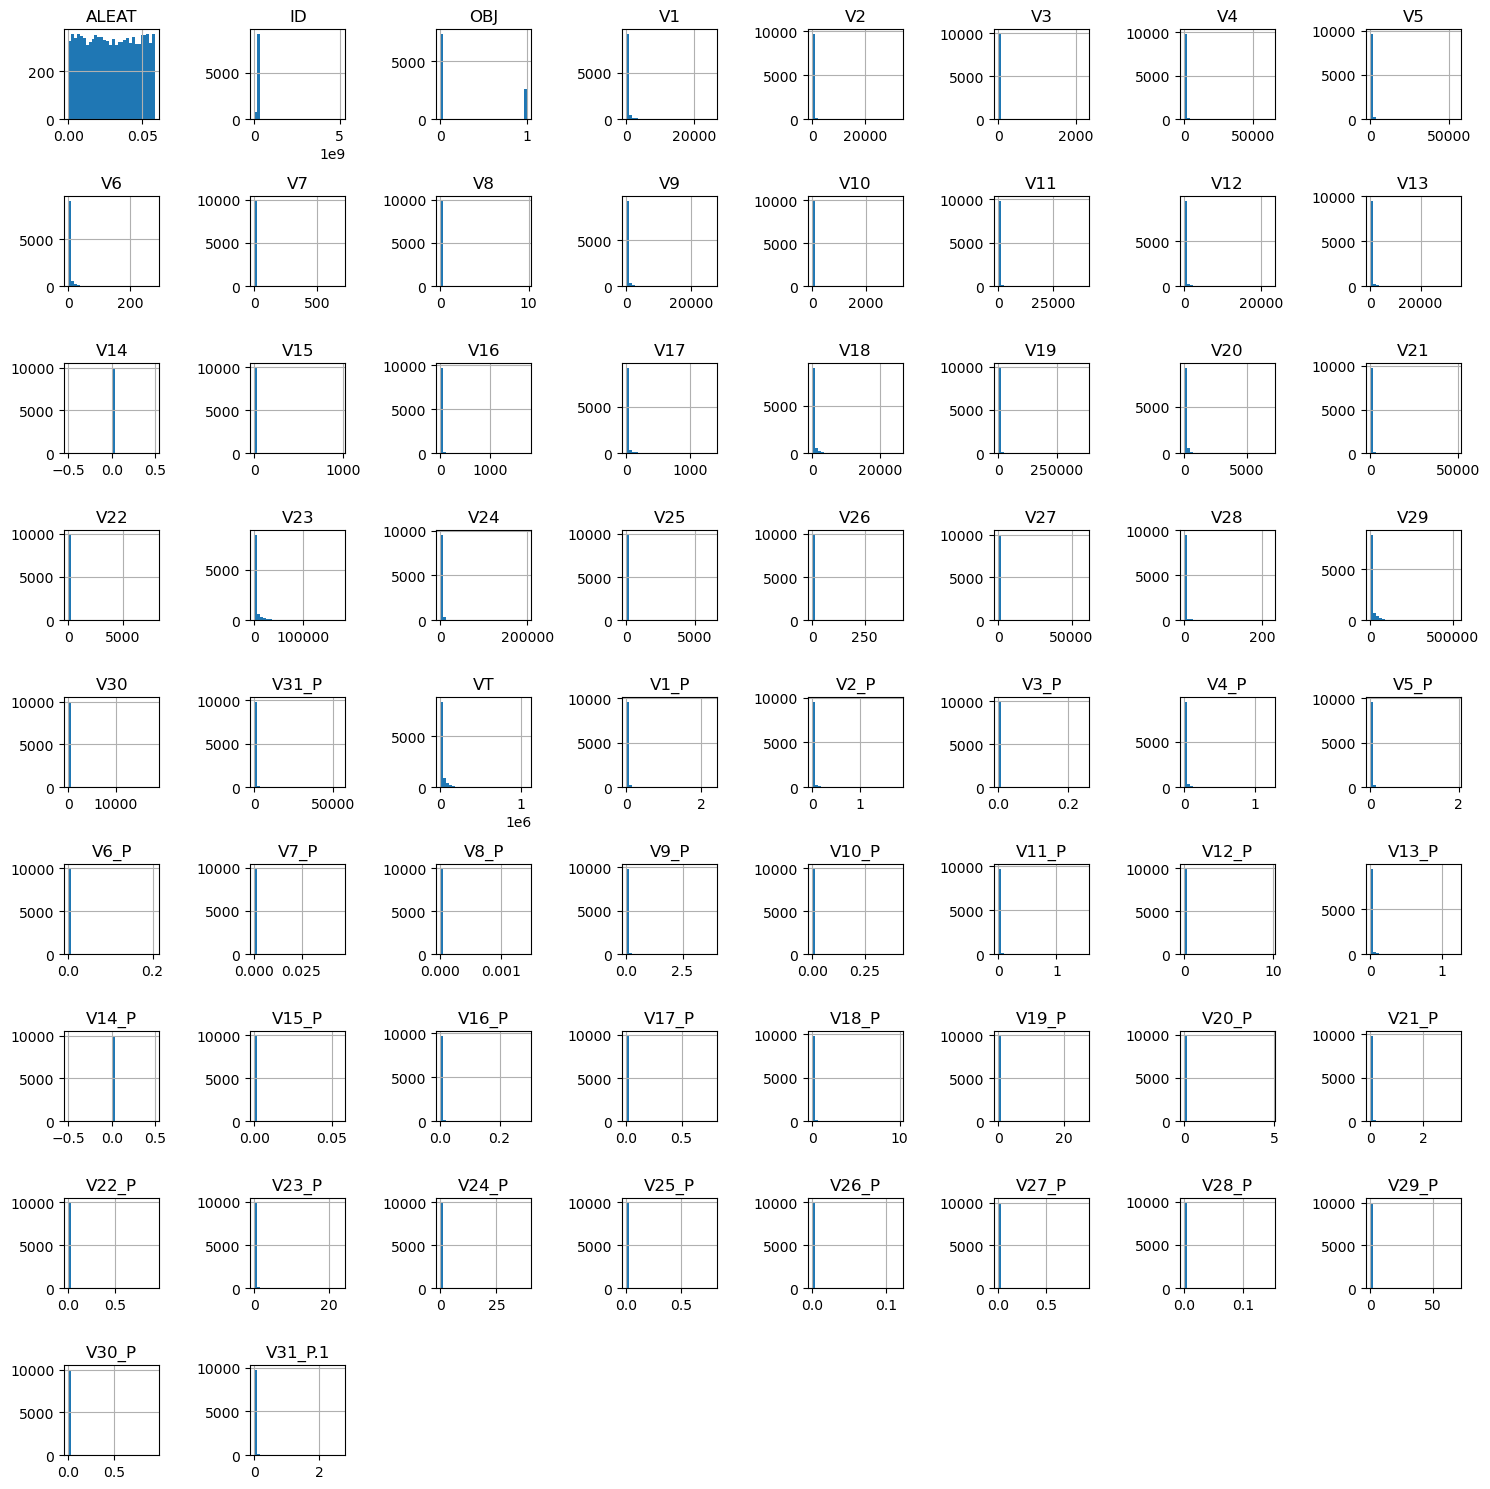

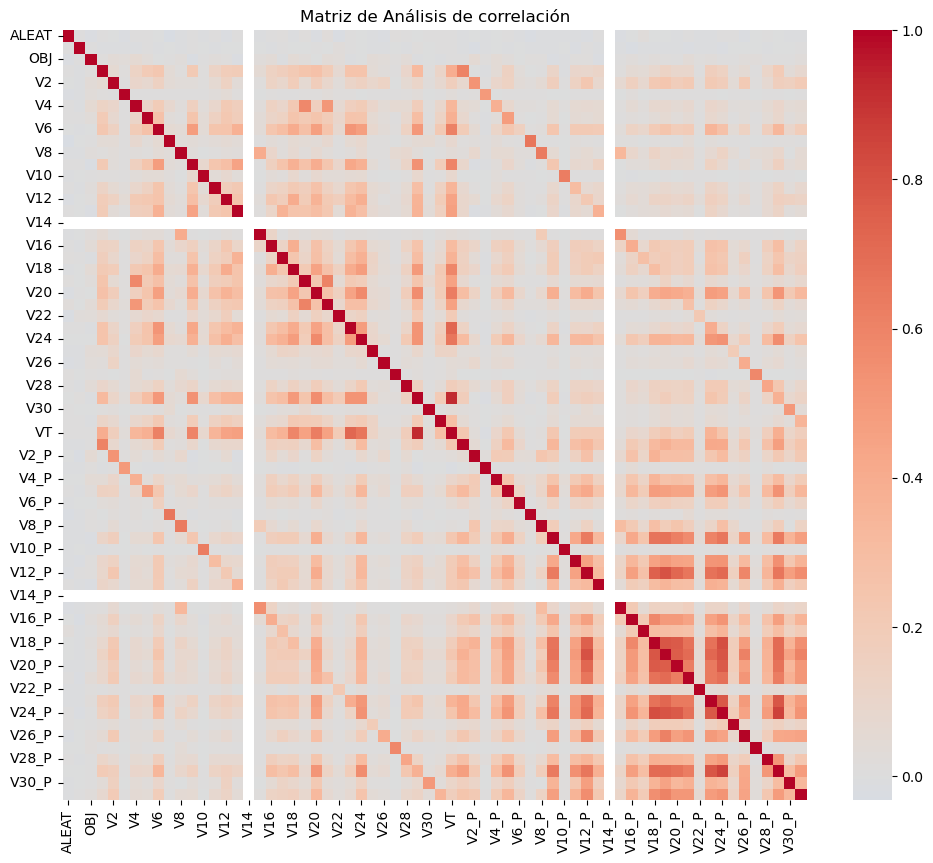


Principales características correlacionadas con el objetivo:
OBJ      1.000000
V4       0.057686
V2_P     0.052559
V4_P     0.046250
V18      0.041480
V21_P    0.038599
V2       0.037323
V16      0.035592
V28      0.034582
V21      0.033947
V25      0.032404
V22      0.032132
V26      0.025945
V9       0.025846
V5       0.025720
Name: OBJ, dtype: float64


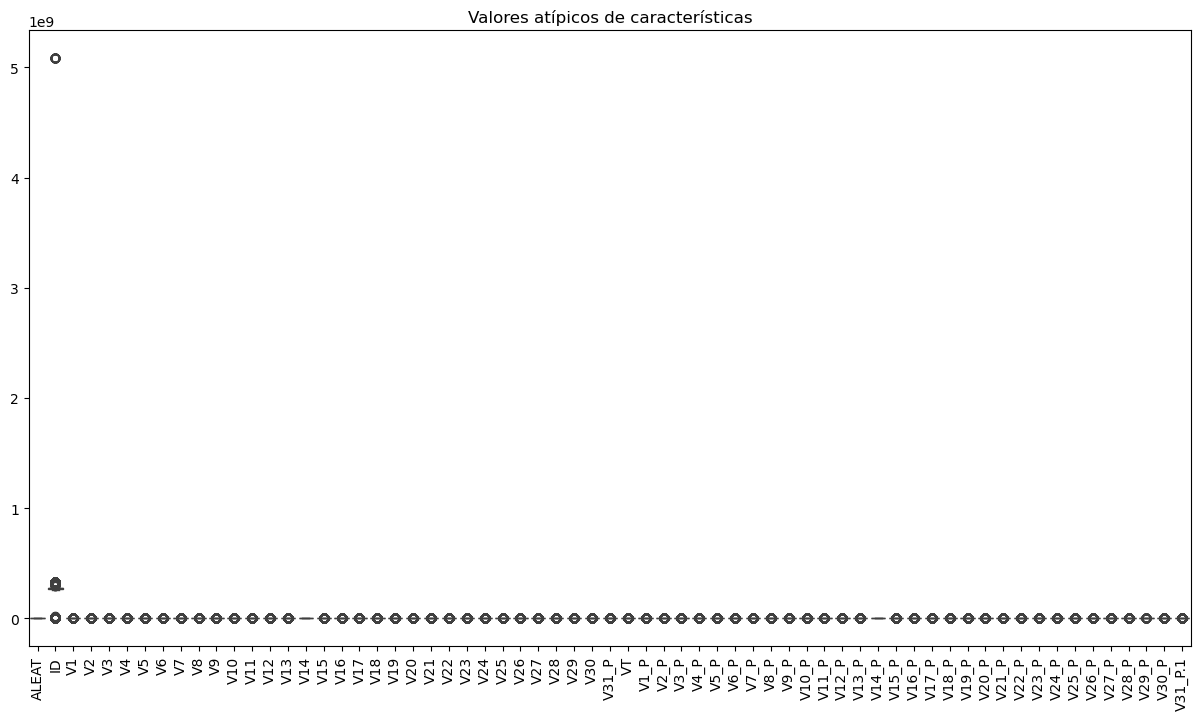

In [3]:
# ======================
#  INVESTIGACIÓN DE LA CALIDAD DE LOS DATOS
# ======================
print("\n=== ANÁLISIS DE CALIDAD DE DATOS ===")

# 1. Distribución de clases
class_dist = data['OBJ'].value_counts(normalize=True)
print(f"Distribución de clases:\n{class_dist}")

# 2. Feature Distributions
plt.figure(figsize=(15, 10))
data.hist(bins=30, figsize=(15, 15))
plt.tight_layout()
plt.savefig('Distribuciones_de_características.png')
plt.show()

# 3. Análisis de correlación
plt.figure(figsize=(12, 10))
corr_matrix = data.corr()
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title('Matriz de Análisis de correlación')
plt.savefig('Matriz_de_correlación.png')
plt.show()

# 4. Comprobación de fugas
target_corr = corr_matrix['OBJ'].abs().sort_values(ascending=False)
print("\nPrincipales características correlacionadas con el objetivo:")
print(target_corr.head(15))

# 5. Detección de valores atípicos
plt.figure(figsize=(15, 8))
sns.boxplot(data=data.drop('OBJ', axis=1))
plt.title('Valores atípicos de características')
plt.xticks(rotation=90)
plt.savefig('outliers.png')
plt.show()

In [4]:
# ======================
#  INGENIERÍA DE CARACTERÍSTICAS
# ======================
print("\n=== INGENIERÍA DE CARACTERÍSTICAS ===")

# 1. Funciones de interacción
print("Creando funciones de interacción...")
for i in range(1, 6):
    for j in range(i+1, 7):
        if f'V{i}' in data.columns and f'V{j}' in data.columns:
            data[f'V{i}_V{j}_int'] = data[f'V{i}'] * data[f'V{j}']
            data[f'V{i}_V{j}_diff'] = data[f'V{i}'] - data[f'V{j}']

# 2. Características polinómicas
print("Creando características polinómicas...")
poly_features = data[[f'V{i}' for i in range(1, 6) if f'V{i}' in data.columns]]
if not poly_features.empty:
    poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
    poly_transformed = poly.fit_transform(poly_features)
    poly_cols = [f'poly_{i}' for i in range(poly_transformed.shape[1])]
    poly_df = pd.DataFrame(poly_transformed, columns=poly_cols)
    data = pd.concat([data, poly_df], axis=1)

# 3. Características específicas del dominio
print("Creando características específicas del dominio...")
if 'abs_sum' in data.columns and 'rel_sum' in data.columns:
    data['abs_rel_ratio'] = data['abs_sum'] / (data['rel_sum'] + 1e-6)
    data['abs_rel_diff'] = data['abs_sum'] - data['rel_sum']

# 4. Características agregadas
print("Creando características agregadas...")
v_cols = [col for col in data.columns if col.startswith('V') and '_' not in col]
if v_cols:
    data['V_mean'] = data[v_cols].mean(axis=1)
    data['V_std'] = data[v_cols].std(axis=1)
    data['V_max'] = data[v_cols].max(axis=1)

print(f"Características totales después de la ingeniería: {data.shape[1]}")


=== INGENIERÍA DE CARACTERÍSTICAS ===
Creando funciones de interacción...
Creando características polinómicas...
Creando características específicas del dominio...
Creando características agregadas...
Características totales después de la ingeniería: 114


In [5]:
# ======================
#  PREPARACIÓN DE DATOS
# ======================
print("\nPreparación de datos para el modelado...")

# Selección de funciones y target
X = data.drop('OBJ', axis=1)
y = data['OBJ']

# División en Train y Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training shape: {X_train.shape}, Test shape: {X_test.shape}")


Preparación de datos para el modelado...
Training shape: (8000, 113), Test shape: (2000, 113)


In [6]:
# ======================
#  MANEJO DEL DESEQUILIBRIO DE CLASE
# ======================
print("\nManejo del desequilibrio de clases...")

# SMOTE
smote = SMOTE(sampling_strategy=0.5, random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print(f"Training shape remuestreado: {X_train_res.shape}")

# Calculo de pesos de clase
class_ratio = y_train.value_counts()[0] / y_train.value_counts()[1]
print(f"Proporción de clases (0:1): {class_ratio:.2f}:1")


Manejo del desequilibrio de clases...
Training shape remuestreado: (8857, 113)
Proporción de clases (0:1): 2.82:1


In [7]:
# ======================
#  PIPELINES DE MODELOS
# ======================

# Random Forest
rf_pipe = ImbPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42, sampling_strategy='minority')),
    ('clf', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

# XGBoost
xgb_pipe = ImbPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42, sampling_strategy='minority')),
    ('clf', XGBClassifier(random_state=42, eval_metric='logloss',
                          scale_pos_weight=class_dist[0]/class_dist[1]))
])


In [8]:
# ======================
#  GRIDS DE HIPERPARÁMETROS
# ======================

# Random Forest
rf_params = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [5, 10, None],
    'clf__min_samples_split': [2, 5],
    'clf__min_samples_leaf': [1, 2]
}

# XGBoost
xgb_params = {
    'clf__learning_rate': [0.01, 0.05, 0.1],
    'clf__max_depth': [3, 5, 7],
    'clf__n_estimators': [100, 200, 300],
    # Añadido de L1/L2 para contrarestar el sobreajuste
    'clf__reg_alpha': [0, 0.1, 0.5],
    'clf__reg_lambda': [1, 1.5, 2],
    # Ajuste del costo de clasificar erróneamente la clase positiva
    # La proporción entre muestras negativas y positivas es de ~3,3, por lo que se prueban valores cercanos.
    'clf__scale_pos_weight': [2.5, 3.3, 4.0, 5.0]
}

In [9]:
# ======================
#  ENTRENAMIENTO DE MODELOS
# ======================
models = {
    'RandomForest': (rf_pipe, rf_params),
    'XGBoost': (xgb_pipe, xgb_params)
}

best_models = {}
results = []
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

print("\n=== ENTRENAMIENTO DE MODELOS ===")
for name, (pipe, params) in models.items():
    print(f"\n{'='*40}")
    print(f"Entrenando {name}...")
    print(f"{'='*40}")

    try:
        # Grid Search con manejo de errores
        gs = GridSearchCV(
            estimator=pipe,
            param_grid=params,
            scoring='f1',
            cv=cv,
            n_jobs=-1,
            verbose=1,
            error_score='raise'  # Obtención de errores detallados
        )
        gs.fit(X_train, y_train)

        # Almacenar el mejor modelo
        best_models[name] = gs.best_estimator_

        # Predicciones
        y_pred = gs.predict(X_test)
        y_proba = gs.predict_proba(X_test)[:, 1]

        # Métricas
        metrics = {
            'Model': name,
            'Best Params': gs.best_params_,
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred, zero_division=0),
            'Recall': recall_score(y_test, y_pred),
            'F1-Score': f1_score(y_test, y_pred),
            'ROC-AUC': roc_auc_score(y_test, y_proba)
        }
        results.append(metrics)

        print(f"\n{name} Mejores Parametros: {gs.best_params_}")
        print(f"Test ROC-AUC: {metrics['ROC-AUC']:.4f}")
        print(f"Test Recall: {metrics['Recall']:.4f}")

    except Exception as e:
        print(f"\nERROR en {name}: {str(e)}")
        print("Probando la configuración de respaldo...")

        # Retorno al modelo predeterminado sin grid search
        try:
            pipe.set_params(**{k.split('__')[1]: v for k, v in params[0].items()} if isinstance(params, list) else {k.split('__')[1]: v for k, v in params.items()})
            pipe.fit(X_train, y_train)

            y_pred = pipe.predict(X_test)
            y_proba = pipe.predict_proba(X_test)[:, 1]

            metrics = {
                'Model': name + '_Fallback',
                'Best Params': 'Default',
                'Accuracy': accuracy_score(y_test, y_pred),
                'Precision': precision_score(y_test, y_pred, zero_division=0),
                'Recall': recall_score(y_test, y_pred),
                'F1-Score': f1_score(y_test, y_pred),
                'ROC-AUC': roc_auc_score(y_test, y_proba)
            }
            results.append(metrics)

            print(f"Retorno al modelo {name} Rendimiento:")
            print(f"Test ROC-AUC: {metrics['ROC-AUC']:.4f}")

        except Exception as fallback_e:
            print(f"Retorno fallido: {str(fallback_e)}")
            continue


=== ENTRENAMIENTO DE MODELOS ===

Entrenando RandomForest...
Fitting 3 folds for each of 24 candidates, totalling 72 fits

RandomForest Mejores Parametros: {'clf__max_depth': 5, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'clf__n_estimators': 100}
Test ROC-AUC: 0.5932
Test Recall: 0.4885

Entrenando XGBoost...
Fitting 3 folds for each of 972 candidates, totalling 2916 fits

XGBoost Mejores Parametros: {'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__n_estimators': 100, 'clf__reg_alpha': 0.5, 'clf__reg_lambda': 2, 'clf__scale_pos_weight': 2.5}
Test ROC-AUC: 0.5987
Test Recall: 0.7882



=== COMPARACIÓN DE MODELOS ===
          Model                                        Best Params  Accuracy  \
1       XGBoost  {'clf__learning_rate': 0.1, 'clf__max_depth': ...     0.450   
0  RandomForest  {'clf__max_depth': 5, 'clf__min_samples_leaf':...     0.612   

   Precision    Recall  F1-Score   ROC-AUC  
1   0.294579  0.788168  0.428868  0.598747  
0   0.335079  0.488550  0.397516  0.593232  

Mejor Modelo: XGBoost (ROC-AUC: 0.5987)

Threshold óptimo: 0.3921 (default=0.5)

Rendimiento optimizado:
Accuracy: 0.3675
Precision: 0.2824
Recall: 0.9179
F1-Score: 0.4320


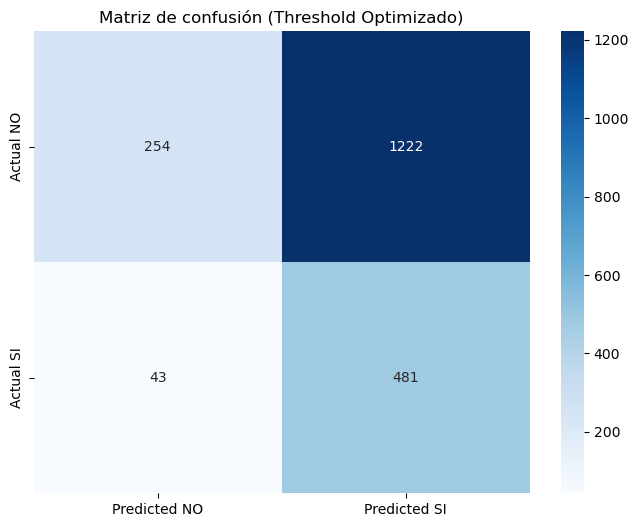


Se guardó el mejor modelo como 'best_model.pkl'


In [10]:
# ======================
#  ANÁLISIS DE RESULTADOS
# ======================
if results:
    results_df = pd.DataFrame(results)
    print("\n=== COMPARACIÓN DE MODELOS ===")
    print(results_df.sort_values('ROC-AUC', ascending=False))

    # Selección del mejor modelo
    best_model_name = results_df.loc[results_df['ROC-AUC'].idxmax(), 'Model']
    best_model = best_models[best_model_name]
    print(f"\nMejor Modelo: {best_model_name} (ROC-AUC: {results_df['ROC-AUC'].max():.4f})")

    # Optimización de threshold
    y_proba = best_model.predict_proba(X_test)[:, 1]
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-6)
    best_threshold = thresholds[np.argmax(f1_scores)]

    print(f"\nThreshold óptimo: {best_threshold:.4f} (default=0.5)")
    y_pred_opt = (y_proba >= best_threshold).astype(int)

    print("\nRendimiento optimizado:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred_opt):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred_opt, zero_division=0):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred_opt):.4f}")
    print(f"F1-Score: {f1_score(y_test, y_pred_opt):.4f}")

    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred_opt)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted NO', 'Predicted SI'],
                yticklabels=['Actual NO', 'Actual SI'])
    plt.title('Matriz de confusión (Threshold Optimizado)')
    plt.savefig('confusion_matrix.png')
    plt.show()

    # Guardar el mejor modelo
    joblib.dump(best_model, 'best_model.pkl')
    print("\nSe guardó el mejor modelo como 'best_model.pkl'")
else:
    print("\nNingún modelo se entrenó correctamente")

In [11]:
# ======================
#  COMBINACIÓN DE MODELOS
# ======================
if best_models:
    print("\n=== COMBINACIÓN DE MODELOS ===")

    # Lista de los mejores modelos
    estimators = [(name, model) for name, model in best_models.items()]

    # Clasificación
    stacking = StackingClassifier(
        estimators=estimators,
        final_estimator=LogisticRegression(max_iter=5000, class_weight='balanced'),
        cv=cv,
        n_jobs=-1
    )

    # Entrenamiento de los modelos combinados
    stacking.fit(X_train_res, y_train_res)

    # Evaluación
    y_pred_stack = stacking.predict(X_test)
    y_proba_stack = stacking.predict_proba(X_test)[:, 1]

    stack_metrics = {
        'Model': 'Stacking_Ensemble',
        'Accuracy': accuracy_score(y_test, y_pred_stack),
        'Precision': precision_score(y_test, y_pred_stack, zero_division=0),
        'Recall': recall_score(y_test, y_pred_stack),
        'F1-Score': f1_score(y_test, y_pred_stack),
        'ROC-AUC': roc_auc_score(y_test, y_proba_stack)
    }

    print("\nRendimiento de los modelos combinados:")
    for metric, value in stack_metrics.items():
        if metric != 'Model':
            print(f"{metric}: {value:.4f}")

    # Comparación con el mejor modelo Sencillo
    if results:
        print("\nComparación con el mejor modelo Sencillo:")
        best_roc = results_df['ROC-AUC'].max()
        print(f"Mejor Modelo Sencillo ROC-AUC: {best_roc:.4f}")
        print(f"Modelo Combinado ROC-AUC: {stack_metrics['ROC-AUC']:.4f}")
        improvement = (stack_metrics['ROC-AUC'] - best_roc) / best_roc * 100
        print(f"Mejoras: {improvement:.2f}%")

    # Guardado del modelo combinado
    joblib.dump(stacking, 'stacking_model.pkl')
    print("\nSe guardó el modelo combinado como 'stacking_model.pkl'")
else:
    print("\nNo existen modelos disponibles para realizar una combinación")


=== COMBINACIÓN DE MODELOS ===

Rendimiento de los modelos combinados:
Accuracy: 0.5975
Precision: 0.3337
Recall: 0.5382
F1-Score: 0.4120
ROC-AUC: 0.6021

Comparación con el mejor modelo Sencillo:
Mejor Modelo Sencillo ROC-AUC: 0.5987
Modelo Combinado ROC-AUC: 0.6021
Mejoras: 0.55%

Se guardó el modelo combinado como 'stacking_model.pkl'
